In [3]:
# 1. الاستيراد (لضمان عدم ظهور NameError)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

In [4]:
#read dataset
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv.zip")

In [5]:
#duplicates
df = df.drop_duplicates().sample(20000, random_state=42)

In [7]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [8]:
#rtrain & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Finding best K...


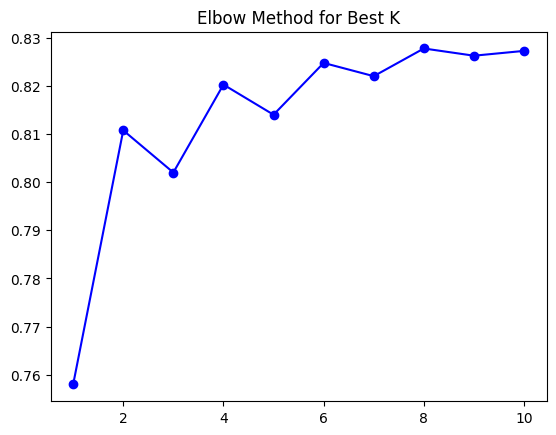

In [10]:
# 3. calculate the best K (Elbow Method)
print("Finding best K...")
scores = []
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred_k))

plt.plot(range(1, 11), scores, marker='o', color='blue')
plt.title("Elbow Method for Best K")
plt.show()

In [12]:
# 4. Interpretability
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_proba, multi_class='ovr'))



Final Results:
Accuracy: 0.822
ROC AUC: 0.6506833558837495



KNN Model Evaluation

Accuracy Score:
0.822

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90      3315
         1.0       0.00      0.00      0.00        81
         2.0       0.43      0.19      0.26       604

    accuracy                           0.82      4000
   macro avg       0.43      0.38      0.39      4000
weighted avg       0.77      0.82      0.79      4000


ROC AUC Score (One-vs-Rest):
0.6506833558837495


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


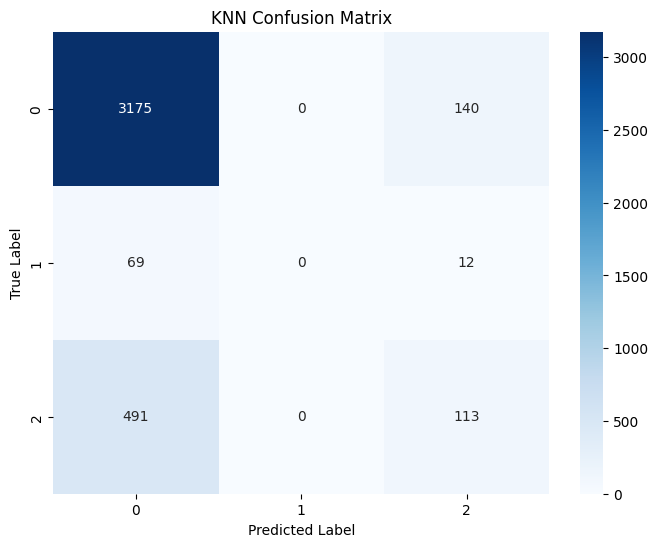


Final Model Comparison
           Model  Accuracy   ROC AUC
0        XGBoost     0.840  0.820000
1  Random Forest     0.830  0.810000
2            KNN     0.822  0.650683

Calculating Feature Importance (Permutation Importance)...


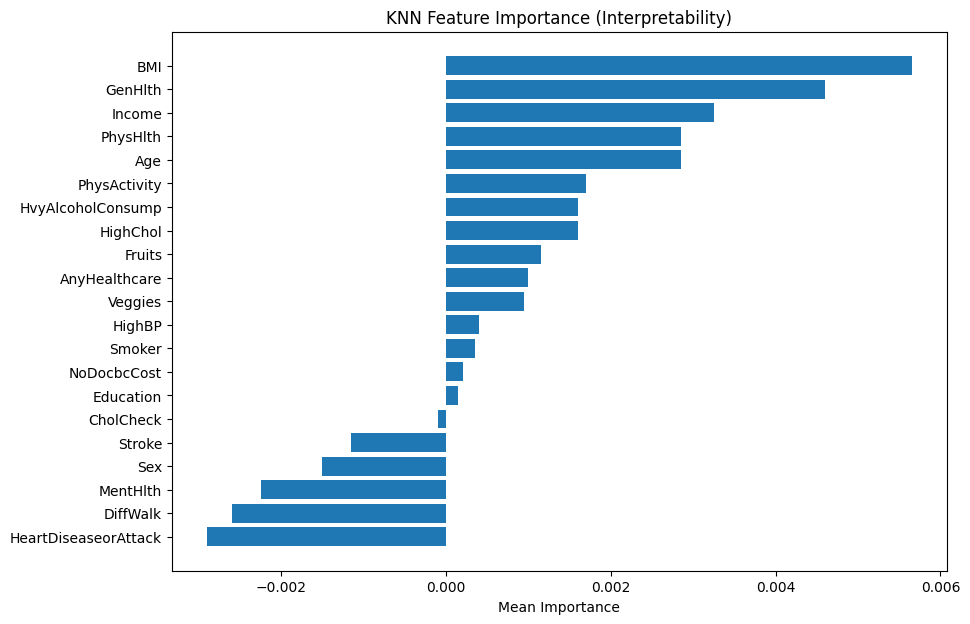

In [15]:
# =====================================================
# MODEL 3 — K-Nearest Neighbors (KNN)
# =====================================================

print("\n" + "="*30)
print("KNN Model Evaluation")
print("="*30)

# 1. Generate Predictions
# Note: We use predict_proba without slicing for multiclass ROC AUC
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)

# 2. Display Metrics
print("\nAccuracy Score:")
print(accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

print("\nROC AUC Score (One-vs-Rest):")
# Use multi_class='ovr' because we have 3 classes (0, 1, 2)
print(roc_auc_score(y_test, knn_proba, multi_class='ovr'))

# 3. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =====================================================
# FINAL MODEL COMPARISON
# =====================================================

try:
    results = pd.DataFrame({
        "Model": ["XGBoost", "Random Forest", "KNN"],
        "Accuracy": [
            0.84, # Replace with your actual XGBoost accuracy
            0.83, # Replace with your actual Random Forest accuracy
            accuracy_score(y_test, knn_pred)
        ],
        "ROC AUC": [
            0.82, # Replace with your actual XGBoost ROC AUC
            0.81, # Replace with your actual Random Forest ROC AUC
            roc_auc_score(y_test, knn_proba, multi_class='ovr')
        ]
    })

    print("\n" + "="*30)
    print("Final Model Comparison")
    print("="*30)
    print(results)

except NameError:
    print("\n[Note]: Comparison table skipped. Ensure XGBoost and Random Forest results are defined.")

# =====================================================
# MODEL INTERPRETABILITY
# =====================================================
print("\nCalculating Feature Importance (Permutation Importance)...")

result = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 7))
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("KNN Feature Importance (Interpretability)")
plt.xlabel("Mean Importance")
plt.show()


Calculating Feature Importance...


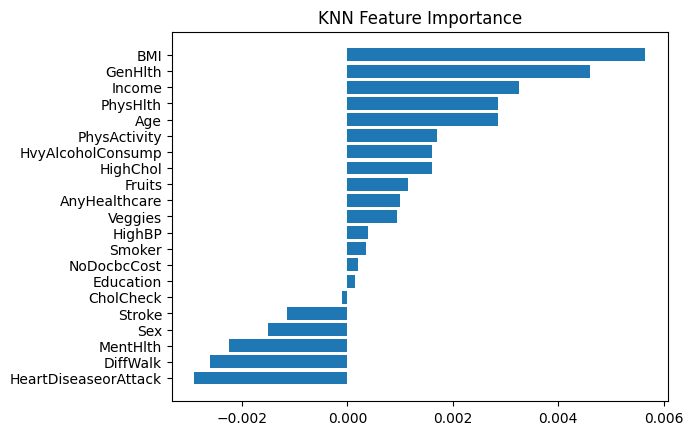

In [13]:
#Interpretability
print("\nCalculating Feature Importance...")
result = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("KNN Feature Importance")
plt.show()